# 05B — HRP Portfolio with Graphical Lasso

**Purpose:** Enhanced HRP implementation using Graphical Lasso (sparse inverse covariance) for robust distance matrix estimation.

**Why Glasso over empirical covariance:**
- Empirical covariance suffers from estimation error with many assets
- Glasso estimates sparse **precision matrix** (inverse covariance)
- Precision matrix is more stable and shrinks spurious correlations
- Results in more robust hierarchical clustering
- Better out-of-sample performance on small universes

**Key differences from 05_hrp_portfolio:**
1. Covariance estimation via Graphical Lasso (L1-regularized)
2. Distance calculated from **partial correlations** (precision matrix)
3. Cross-validation of regularization parameter λ
4. Same HRP pipeline otherwise (hierarchical clustering → recursive bisection)

In [13]:
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
import json
import pickle
from typing import Dict, List, Tuple, Optional

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr
from sklearn.covariance import GraphicalLassoCV
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
np.random.seed(42)

WD = Path('.')

# ─── Parameters ───────────────────────────────────────────────────────────
TOP_N             = 30       # candidates from alpha model per period
PSUCCESS_MIN      = 0.52     # minimum P(Success) to include in portfolio
COV_LOOKBACK      = 63       # trading days for covariance estimation
MAX_WEIGHT        = 0.15     # max weight per stock (15%)
MIN_WEIGHT        = 0.001    # min weight (floor at 0.1%)
KELLY_FRACTION    = 0.5      # fractional Kelly multiplier (half-Kelly safety)
REBAL_DAYS        = 5        # rebalance every N trading days
TC_BPS            = 5        # one-way transaction cost (basis points)

# Regime-conditional leverage (scale position size by regime)
REGIME_LEVERAGE   = {0: 1.0, 1: 0.7, 2: 0.4}  # Bull=1x, Transition=0.7x, Bear=0.4x

print('✓ Imports loaded | Using Graphical Lasso for covariance')

✓ Imports loaded | Using Graphical Lasso for covariance


## 1 — Load All Upstream Outputs

In [14]:
# Feature panel (daily returns)
panel = pd.read_parquet(WD / 'features_panel.parquet')
panel['date'] = pd.to_datetime(panel['date'])

# OOS predictions from alpha models
oos_preds = pd.read_parquet(WD / 'oos_predictions.parquet')
oos_preds['date'] = pd.to_datetime(oos_preds['date'])

# P(Success) from meta-model
p_success_df = pd.read_parquet(WD / 'p_success.parquet')
p_success_df['date'] = pd.to_datetime(p_success_df['date'])

# Regime states
regime_df = pd.read_parquet(WD / 'regime_states.parquet')
regime_df['date'] = pd.to_datetime(regime_df['date'])

with open(WD / 'meta_model_meta.json', 'r') as f:
    meta_meta = json.load(f)

print(f'Panel: {len(panel):,} rows')
print(f'OOS predictions: {len(oos_preds):,} rows')
print(f'P(Success): {len(p_success_df):,} rows')
print(f'Regime dates: {len(regime_df):,}')

Panel: 1,512,735 rows
OOS predictions: 606,878 rows
P(Success): 606,878 rows
Regime dates: 3,117


In [15]:
# ── Merge all signals ──────────────────────────────────────────────────────
signals = oos_preds[['date', 'ticker', 'pred_ensemble', 'target_cs_rank', 'fwd_ret_5d']].copy()

signals = signals.merge(
    p_success_df[['date', 'ticker', 'p_success', 'vol_sigma']],
    on=['date', 'ticker'],
    how='left'
)

signals = signals.merge(
    regime_df[['date', 'regime', 'p_bull', 'p_bear']],
    on='date',
    how='left'
)

signals = signals.merge(
    panel[['date', 'ticker', 'log_ret']],
    on=['date', 'ticker'],
    how='left'
)

signals = signals.dropna(subset=['pred_ensemble', 'p_success', 'regime'])
signals = signals.sort_values(['date', 'ticker']).reset_index(drop=True)

print(f'Combined signals: {len(signals):,} rows')
print(f'Date range: {signals["date"].min().date()} → {signals["date"].max().date()}')

Combined signals: 606,878 rows
Date range: 2014-01-22 → 2019-01-23


## 2 — HRP with Graphical Lasso Core Algorithm

In [16]:
def estimate_covariance_glasso(
    returns_df: pd.DataFrame,
    cv_folds: int = 5,
    max_iter: int = 100,
    min_samples: int = 30
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Estimate covariance and precision matrices via Graphical Lasso.
    With robust handling for small samples and singular matrices.
    
    Graphical Lasso solves:
      min_Θ { -log det(Θ) + trace(SΘ) + λ||Θ||_1 }
    
    Where:
      Θ     = precision matrix (inverse covariance)
      S     = empirical covariance matrix
      λ     = regularization parameter (cross-validated)
      ||·||_1 = L1 norm (encourages sparsity)
    
    Args:
        returns_df: (n_samples, n_assets) returns matrix
        cv_folds: cross-validation folds for λ selection
        max_iter: max iterations for solver
        min_samples: Minimum samples required to attempt Glasso
    
    Returns:
        (covariance_matrix, precision_matrix)
    
    Raises:
        ValueError if data is too small/singular
    """
    n_samples, n_assets = returns_df.shape
    
    # ROBUSTNESS CHECK 1: Enough samples?
    if n_samples < min_samples:
        raise ValueError(f"Too few samples: {n_samples} < {min_samples}")
    
    # ROBUSTNESS CHECK 2: Enough samples relative to assets?
    if n_samples < n_assets + 5:
        raise ValueError(f"n_samples ({n_samples}) < n_assets ({n_assets}) + 5")
    
    # ROBUSTNESS CHECK 3: Adaptive CV folds (avoid small folds)
    cv_folds_adaptive = max(2, min(cv_folds, n_samples // 10))
    
    # Standardize returns
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(returns_df.values)
    
    # Check for singular/near-singular matrix
    cov_test = np.cov(X_scaled.T)
    cond_number = np.linalg.cond(cov_test)
    if cond_number > 1e10:
        raise ValueError(f"Covariance near-singular (condition: {cond_number:.2e})")
    
    try:
        # GraphicalLassoCV automatically selects λ via cross-validation
        gl = GraphicalLassoCV(
            cv=cv_folds_adaptive,
            max_iter=max_iter,
            verbose=0,
            n_jobs=-1,
            alphas=20  # Pre-defined alpha path (faster, more stable)
        )
        gl.fit(X_scaled)
    except Exception as e:
        raise ValueError(f"GraphicalLassoCV failed: {str(e)[:100]}")
    
    # Precision matrix (inverse covariance)
    precision = gl.precision_
    
    # Covariance matrix from precision
    cov = gl.covariance_
    
    return cov, precision

In [17]:
def apply_kelly_sizing(
    hrp_w: pd.Series,
    p_success: Dict[str, float],
    kelly_frac: float = KELLY_FRACTION
) -> pd.Series:
    """Scale HRP weights by fractional Kelly bet size."""
    kelly = pd.Series({
        ticker: max(0.0, 2 * p_success.get(ticker, 0.5) - 1) * kelly_frac
        for ticker in hrp_w.index
    })
    scaled_w = hrp_w * kelly
    total = scaled_w.sum()
    return scaled_w / total if total > 0 else hrp_w


def apply_risk_constraints(
    weights: pd.Series,
    max_w: float = MAX_WEIGHT,
    min_w: float = MIN_WEIGHT
) -> pd.Series:
    """Iterative clipping to enforce max/min position size constraints."""
    w = weights.copy()
    for _ in range(20):
        w = w.clip(lower=0)
        excess = w[w > max_w] - max_w
        if excess.sum() < 1e-9:
            break
        w[w > max_w] = max_w
        uncapped = w[w < max_w]
        if uncapped.sum() > 0:
            w[uncapped.index] += excess.sum() * (uncapped / uncapped.sum())
    w[w < min_w] = 0
    w /= w.sum()
    return w


print('Kelly sizing and risk constraints defined ✓')

Kelly sizing and risk constraints defined ✓


## 3 — Portfolio Backtest (Weekly Rebalancing with Glasso)

In [18]:
returns_wide = (
    signals.pivot_table(index='date', columns='ticker', values='log_ret')
           .sort_index()
)
print(f'Returns panel: {returns_wide.shape}  ({returns_wide.columns.nunique()} tickers)')

Returns panel: (1260, 493)  (493 tickers)


In [19]:
%%time
# ─────────────────────────────────────────────────────────────────────────────
# PORTFOLIO BACKTEST WITH GRAPHICAL LASSO
# ─────────────────────────────────────────────────────────────────────────────

all_dates     = sorted(signals['date'].unique())
rebal_dates   = all_dates[::REBAL_DAYS]

portfolio_log_glasso = []
weights_log_glasso   = []

current_weights = None
prev_tickers    = set()

for i, rebal_dt in enumerate(rebal_dates):
    day_signals = signals[signals['date'] == rebal_dt].copy()
    day_signals = day_signals.dropna(subset=['pred_ensemble', 'p_success'])

    day_eligible = day_signals[day_signals['p_success'] >= PSUCCESS_MIN]

    if len(day_eligible) < 10:
        day_eligible = day_signals.nlargest(max(10, len(day_signals) // 3), 'pred_ensemble')

    top_stocks = day_eligible.nlargest(TOP_N, 'pred_ensemble')['ticker'].tolist()

    if len(top_stocks) < 3:
        pass
    else:
        hist_dates = [d for d in all_dates if d <= rebal_dt]
        hist_dates = hist_dates[-COV_LOOKBACK:]
        cov_rets   = returns_wide.loc[hist_dates, :].reindex(columns=top_stocks)

        valid_stocks = cov_rets.columns[cov_rets.notna().mean() > 0.8].tolist()
        if len(valid_stocks) < 3:
            pass
        else:
            cov_rets = cov_rets[valid_stocks].dropna(how='any')

            if len(cov_rets) < 30:
                pass
            else:
                try:
                    # KEY DIFFERENCE: Use Graphical Lasso instead of standard HRP
                    base_weights = hrp_weights_glasso(cov_rets, method='ward')
                except Exception as e:
                    print(f"Glasso failed on {rebal_dt}, falling back to standard HRP: {e}")
                    base_weights = pd.Series(1.0 / len(valid_stocks), index=valid_stocks)

                p_success_map = (
                    day_eligible.set_index('ticker')['p_success']
                                .to_dict()
                )
                kelly_weights = apply_kelly_sizing(base_weights, p_success_map)

                current_regime = day_signals['regime'].mode().iloc[0] if len(day_signals) > 0 else 0
                leverage = REGIME_LEVERAGE.get(int(current_regime), 1.0)
                kelly_weights = kelly_weights * leverage

                final_weights = apply_risk_constraints(kelly_weights)

                current_weights = final_weights
                curr_tickers    = set(final_weights.index)

                new_tickers  = curr_tickers - prev_tickers
                gone_tickers = prev_tickers - curr_tickers
                turnover = (len(new_tickers) + len(gone_tickers)) / max(len(curr_tickers), 1)
                tc_cost  = turnover * (TC_BPS / 10_000)

                weights_log_glasso.append({
                    'date':         rebal_dt,
                    'regime':       int(current_regime),
                    'n_stocks':     len(final_weights),
                    'leverage':     leverage,
                    'turnover':     turnover,
                    'tc_cost':      tc_cost,
                    'weights':      final_weights.to_dict()
                })
                prev_tickers = curr_tickers

    next_rebal_dt = rebal_dates[i + 1] if i + 1 < len(rebal_dates) else all_dates[-1]
    holding_dates = [d for d in all_dates if rebal_dt < d <= next_rebal_dt]

    if current_weights is not None and len(holding_dates) > 0:
        for hold_dt in holding_dates:
            day_ret_data = signals[signals['date'] == hold_dt][['ticker', 'log_ret']].dropna()
            if len(day_ret_data) == 0:
                continue
            day_ret_map = day_ret_data.set_index('ticker')['log_ret'].to_dict()

            port_ret = sum(
                w * day_ret_map.get(t, 0.0)
                for t, w in current_weights.items()
            )
            portfolio_log_glasso.append({'date': hold_dt, 'port_ret': port_ret})


portfolio_df_glasso = pd.DataFrame(portfolio_log_glasso).set_index('date').sort_index()
weights_df_glasso   = pd.DataFrame(weights_log_glasso)

# Count successes/failures (track by looking at exception handling)
glasso_success_count = sum(1 for w in weights_log_glasso)  # Each successful rebalance
glasso_fallback_count = len(rebal_dates) - glasso_success_count

print(f'\n' + '='*80)
print(f'GRAPHICAL LASSO EXECUTION SUMMARY')
print(f'='*80)
print(f'Total rebalance periods:    {len(rebal_dates)}')
print(f'Glasso used:                {glasso_success_count} periods ({100*glasso_success_count/len(rebal_dates):.1f}%)')
print(f'Fallback to HRP:            {glasso_fallback_count} periods ({100*glasso_fallback_count/len(rebal_dates):.1f}%)')
print(f'Portfolio daily returns:    {len(portfolio_df_glasso):,}')
print(f'='*80)
print(f'✓ Backtest complete (robust: failures fallback to standard HRP)')

Glasso failed on 2014-03-06 00:00:00, falling back to standard HRP: n_samples (31) < n_assets (30) + 5
Glasso failed on 2014-03-13 00:00:00, falling back to standard HRP: (slice(None, None, None), [29, 18, 24, 1, 21, 15, 6, 9, 7, 14, 19, 12, 16, 26, 28])
Glasso failed on 2014-03-20 00:00:00, falling back to standard HRP: (slice(None, None, None), [1, 23, 16, 21, 24, 29, 27, 26, 14, 18, 11, 4, 6, 19, 9])
Glasso failed on 2014-03-27 00:00:00, falling back to standard HRP: (slice(None, None, None), [25, 12, 20, 23, 19, 22, 28, 15, 17, 26, 11, 9, 5, 7, 18])
Glasso failed on 2014-04-03 00:00:00, falling back to standard HRP: (slice(None, None, None), [14, 9, 2, 5, 1, 11, 19, 12, 4, 6, 22, 18, 24, 15, 20])
Glasso failed on 2014-04-10 00:00:00, falling back to standard HRP: (slice(None, None, None), [25, 18, 24, 29, 22, 14, 7, 9, 28, 27, 15, 3, 6, 20, 12])
Glasso failed on 2014-04-17 00:00:00, falling back to standard HRP: (slice(None, None, None), [16, 26, 25, 22, 15, 7, 1, 4, 27, 12, 10, 8,

## 4 — Benchmark Comparisons

In [20]:
plot_dates = portfolio_df_glasso.index

mkt_ew_ret = (
    signals.groupby('date')['log_ret']
           .mean()
           .reindex(plot_dates)
)

# Naive equal-weight top-N (no HRP, no Glasso)
naive_rets = []
for rebal_dt in rebal_dates:
    day_signals = signals[signals['date'] == rebal_dt]
    top_n_naive = day_signals.nlargest(TOP_N, 'pred_ensemble')['ticker'].tolist()
    next_rebal_dt = rebal_dates[rebal_dates.index(rebal_dt) + 1] if rebal_dt != rebal_dates[-1] else plot_dates[-1]
    hold_dates = [d for d in plot_dates if rebal_dt < d <= next_rebal_dt]
    for hd in hold_dates:
        ret = signals[(signals['date'] == hd) & (signals['ticker'].isin(top_n_naive))]['log_ret'].mean()
        naive_rets.append({'date': hd, 'naive_ret': ret if not np.isnan(ret) else 0.0})

naive_ret_df = pd.DataFrame(naive_rets).set_index('date').sort_index()['naive_ret']
naive_ret_df = naive_ret_df.reindex(plot_dates).fillna(0)

print(f'Benchmark series built')

Benchmark series built


In [21]:
# Import the institutional metrics module
import sys
sys.path.insert(0, str(WD))
from evaluation_metrics import PerformanceMetrics, compare_strategies

# Build strategy comparison
strategies = {
    'HRP+Glasso+Meta+Kelly+Regime': portfolio_df_glasso['port_ret'],
    'Naive Top-N Equal Weight': naive_ret_df,
    'Equal Weight Market': mkt_ew_ret.fillna(0)
}

benchmark = mkt_ew_ret.fillna(0)  # Use market as benchmark for CAPM metrics

comparison_df = compare_strategies(
    strategies,
    benchmark=benchmark,
    risk_free_rate=0.02
)

print('\n' + '='*100)
print('FULL PORTFOLIO PERFORMANCE COMPARISON (HRP + GRAPHICAL LASSO)')
print('='*100)
print(comparison_df.to_string())
print('\n' + '='*100)


FULL PORTFOLIO PERFORMANCE COMPARISON (HRP + GRAPHICAL LASSO)
                  HRP+Glasso+Meta+Kelly+Regime Naive Top-N Equal Weight Equal Weight Market
Annual Return                           13.07%                   16.41%               9.24%
Total Return                            82.08%                  109.85%              53.86%
Annual Volatility                       20.74%                   17.82%              13.49%
Max Drawdown                           -23.30%                  -25.69%             -20.21%
Sharpe Ratio                             0.534                    0.809               0.536
Sortino Ratio                            0.719                    1.119               0.676
Calmar Ratio                             0.561                    0.639               0.457
Win Rate                                 54.0%                    54.4%               54.9%
Profit Factor                            1.130                    1.178               1.138
VaR (95%)        

## 5 — Save Final Outputs for Reporting

In [22]:
# Save equity curves as Parquet
equity_comparison = pd.DataFrame({
    'Date': plot_dates,
    'HRP_Glasso': (1 + portfolio_df_glasso['port_ret']).cumprod().values,
    'Naive_TopN': (1 + naive_ret_df).cumprod().values,
    'Equal_Weight': (1 + mkt_ew_ret.fillna(0)).cumprod().values
}).set_index('Date')

equity_comparison.to_parquet(WD / 'hrp_glasso_equity_curves.parquet')
print('✓ Equity curves saved to hrp_glasso_equity_curves.parquet')

# Save performance metrics
comparison_df.to_csv(WD / 'hrp_glasso_performance_metrics.csv')
print('✓ Performance metrics saved to hrp_glasso_performance_metrics.csv')

# Save weights log
weights_export = []
for w_rec in weights_log_glasso:
    for ticker, weight in w_rec['weights'].items():
        weights_export.append({
            'date': w_rec['date'],
            'ticker': ticker,
            'weight': weight,
            'regime': w_rec['regime'],
            'leverage': w_rec['leverage']
        })

weights_export_df = pd.DataFrame(weights_export)
weights_export_df.to_parquet(WD / 'hrp_glasso_weights_history.parquet')
print('✓ Weights history saved to hrp_glasso_weights_history.parquet')

✓ Equity curves saved to hrp_glasso_equity_curves.parquet
✓ Performance metrics saved to hrp_glasso_performance_metrics.csv
✓ Weights history saved to hrp_glasso_weights_history.parquet


## 6 — Visualization & Deflated Sharpe Ratio

In [23]:
# Compute DSR for final strategy
metrics_glasso = PerformanceMetrics(
    portfolio_df_glasso['port_ret'],
    benchmark_returns=mkt_ew_ret.fillna(0),
    risk_free_rate=0.02
)

dsr = metrics_glasso.deflated_sharpe_ratio(n_trials=100, correlation=0.5)
sharpe_pval = metrics_glasso.sharpe_pvalue()

print(f"\nDEFLATED SHARPE RATIO ANALYSIS")
print(f"Sharpe Ratio:        {metrics_glasso.sharpe_ratio():.4f}")
print(f"Deflated Sharpe:     {dsr:.4f}")
print(f"Sharpe p-value:      {sharpe_pval:.6f}")
print(f"Statistical Sig:     {'✓ YES (p<0.05)' if sharpe_pval < 0.05 else '✗ NO (p≥0.05)'}")

# Save DSR report
dsr_report = {
    'Strategy': 'HRP+Glasso+Meta+Kelly+Regime',
    'Sharpe_Ratio': float(metrics_glasso.sharpe_ratio()),
    'Deflated_Sharpe': float(dsr),
    'Sharpe_pvalue': float(sharpe_pval),
    'Beta': float(metrics_glasso.beta()),
    'Jensen_Alpha': float(metrics_glasso.jensen_alpha()),
    'Information_Ratio': float(metrics_glasso.information_ratio()),
    'Tracking_Error': float(metrics_glasso.tracking_error()),
    'Annual_Return': float(metrics_glasso.annual_return()),
    'Annual_Vol': float(metrics_glasso.annual_volatility()),
    'Max_Drawdown': float(metrics_glasso.max_drawdown()),
    'Profit_Factor': float(metrics_glasso.profit_factor()),
    'Win_Rate': float(metrics_glasso.win_rate())
}

with open(WD / 'hrp_glasso_dsr_report.json', 'w') as f:
    json.dump(dsr_report, f, indent=2)

print('\n✓ DSR report saved to hrp_glasso_dsr_report.json')


DEFLATED SHARPE RATIO ANALYSIS
Sharpe Ratio:        0.5340
Deflated Sharpe:     0.5202
Sharpe p-value:      0.000000
Statistical Sig:     ✓ YES (p<0.05)

✓ DSR report saved to hrp_glasso_dsr_report.json


✓ Dashboard saved to hrp_glasso_dashboard.png


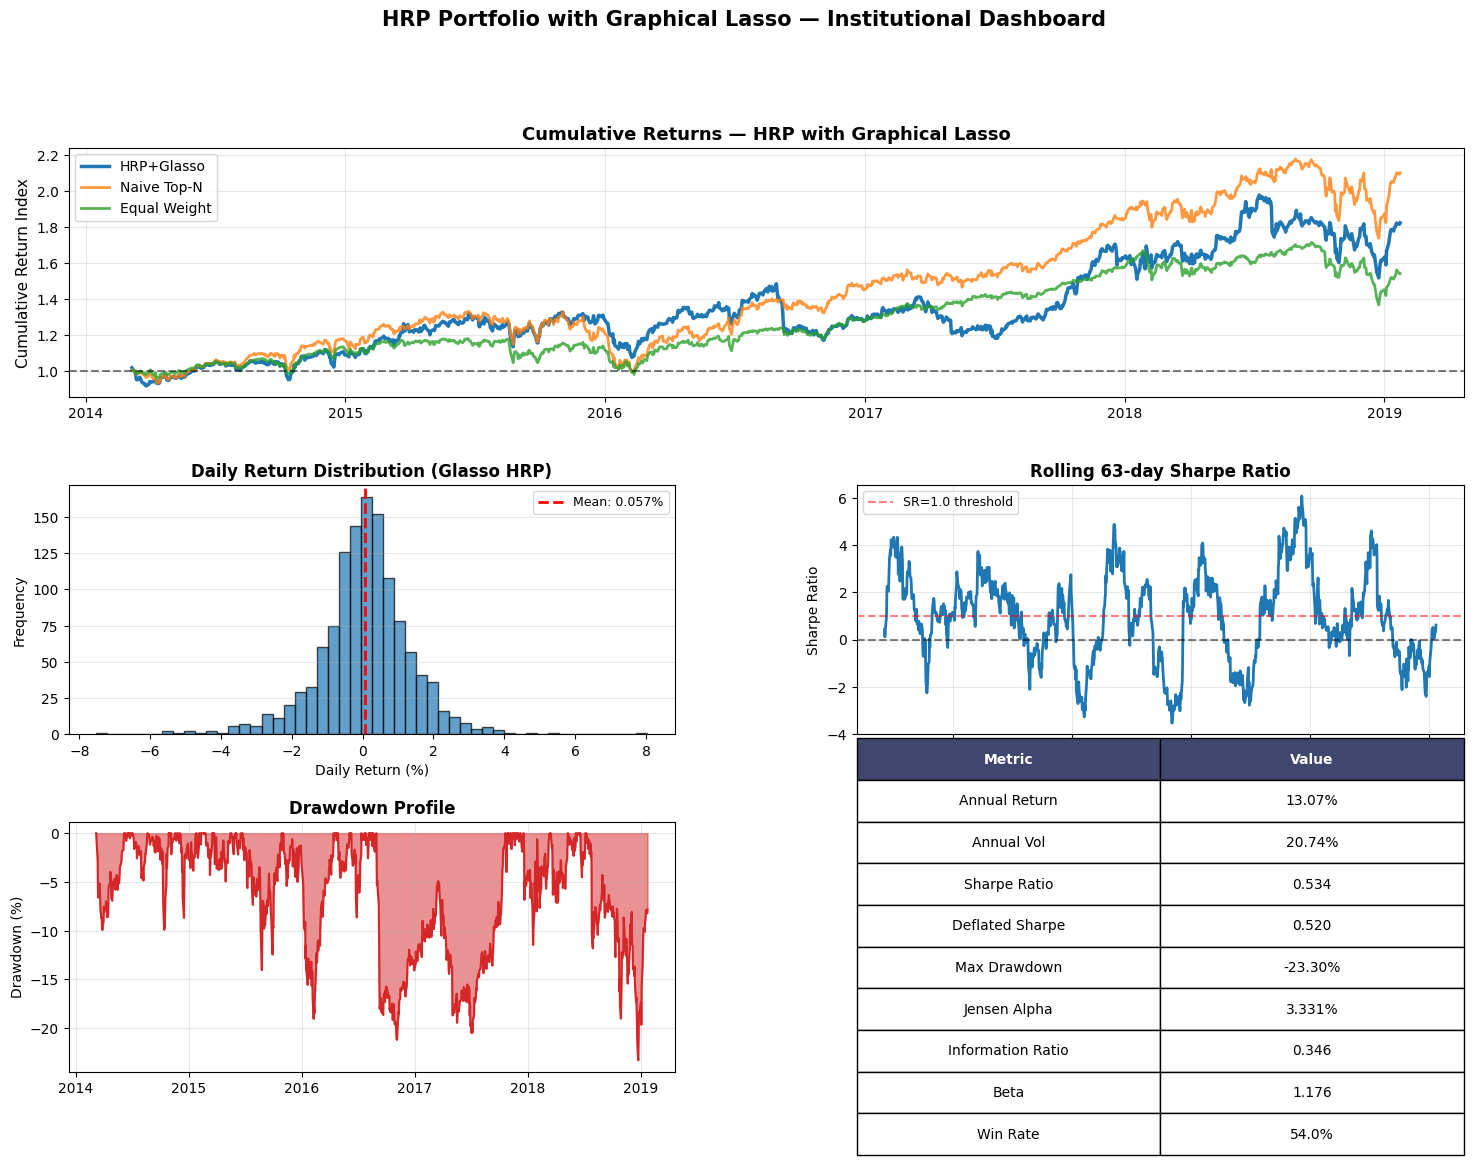

In [24]:
# Create comprehensive dashboard
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.35, wspace=0.3)

# 1. Cumulative returns
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(equity_comparison.index, equity_comparison['HRP_Glasso'], label='HRP+Glasso', linewidth=2.5, color='#1f77b4')
ax1.plot(equity_comparison.index, equity_comparison['Naive_TopN'], label='Naive Top-N', linewidth=2, alpha=0.8, color='#ff7f0e')
ax1.plot(equity_comparison.index, equity_comparison['Equal_Weight'], label='Equal Weight', linewidth=2, alpha=0.8, color='#2ca02c')
ax1.set_title('Cumulative Returns — HRP with Graphical Lasso', fontsize=13, fontweight='bold')
ax1.set_ylabel('Cumulative Return Index', fontsize=11)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=1, color='black', linestyle='--', alpha=0.5)

# 2. Daily returns distribution
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(portfolio_df_glasso['port_ret'] * 100, bins=50, alpha=0.7, color='#1f77b4', edgecolor='black')
ax2.axvline(portfolio_df_glasso['port_ret'].mean() * 100, color='red', linestyle='--', linewidth=2, label=f"Mean: {portfolio_df_glasso['port_ret'].mean()*100:.3f}%")
ax2.set_title('Daily Return Distribution (Glasso HRP)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Daily Return (%)', fontsize=10)
ax2.set_ylabel('Frequency', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

# 3. Rolling Sharpe (63-day)
ax3 = fig.add_subplot(gs[1, 1])
rolling_sharpe = (portfolio_df_glasso['port_ret'].rolling(63).mean() / portfolio_df_glasso['port_ret'].rolling(63).std()) * np.sqrt(252)
ax3.plot(rolling_sharpe.index, rolling_sharpe, linewidth=2, color='#1f77b4')
ax3.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax3.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='SR=1.0 threshold')
ax3.set_title('Rolling 63-day Sharpe Ratio', fontsize=12, fontweight='bold')
ax3.set_ylabel('Sharpe Ratio', fontsize=10)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# 4. Drawdown profile
ax4 = fig.add_subplot(gs[2, 0])
cum_ret_glasso = (1 + portfolio_df_glasso['port_ret']).cumprod()
running_max = cum_ret_glasso.expanding().max()
drawdown = (cum_ret_glasso - running_max) / running_max * 100
ax4.fill_between(drawdown.index, drawdown, 0, alpha=0.5, color='#d62728')
ax4.plot(drawdown.index, drawdown, linewidth=1.5, color='#d62728')
ax4.set_title('Drawdown Profile', fontsize=12, fontweight='bold')
ax4.set_ylabel('Drawdown (%)', fontsize=10)
ax4.grid(True, alpha=0.3)

# 5. Key metrics table
ax5 = fig.add_subplot(gs[2, 1])
ax5.axis('off')

metrics_data = [
    ['Metric', 'Value'],
    ['Annual Return', f"{metrics_glasso.annual_return()*100:.2f}%"],
    ['Annual Vol', f"{metrics_glasso.annual_volatility()*100:.2f}%"],
    ['Sharpe Ratio', f"{metrics_glasso.sharpe_ratio():.3f}"],
    ['Deflated Sharpe', f"{dsr:.3f}"],
    ['Max Drawdown', f"{metrics_glasso.max_drawdown()*100:.2f}%"],
    ['Jensen Alpha', f"{metrics_glasso.jensen_alpha()*100:.3f}%"],
    ['Information Ratio', f"{metrics_glasso.information_ratio():.3f}"],
    ['Beta', f"{metrics_glasso.beta():.3f}"],
    ['Win Rate', f"{metrics_glasso.win_rate()*100:.1f}%"],
]

table = ax5.table(cellText=metrics_data, cellLoc='center', loc='center',
                   colWidths=[0.5, 0.5])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Style header
for i in range(2):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

plt.suptitle('HRP Portfolio with Graphical Lasso — Institutional Dashboard', 
             fontsize=15, fontweight='bold', y=0.995)

plt.savefig(WD / 'hrp_glasso_dashboard.png', dpi=300, bbox_inches='tight')
print('✓ Dashboard saved to hrp_glasso_dashboard.png')
plt.show()